# NYC TIME FIELD — reproducible model audit

## tl;dr

This notebook audits the static data assets behind the interactive site. The
published snapshot contains **6,166 H3 cells**,
**496 parent stations**,
**197 2020 NTAs**, and
**3,662,005 MapPLUTO residential units**.

The model combines OSMnx pedestrian and road shortest paths, three MTA
scheduled service scenarios, and an H3-level 2020–2024 ACS rent surface. Validation
is rerun below directly from the committed browser assets. It is a comparative
accessibility study, not a live journey planner or rental-listing service.

## Context & Methods

The research question is: **How does a fixed commute budget reorganize New
York when the reader switches between subway, driving, and walking—and what
housing context appears when bar height changes to estimated gross rent?**

### Reproducible model

1. Clip NYC Planning 2020 NTAs and create an H3 resolution 9 grid.
2. Spatially join MapPLUTO `UnitsRes` to cells and NTAs.
3. Download five-borough OSM pedestrian and directed road graphs. Snap cells
   plus actual MTA entrances/exits to the pedestrian graph.
4. Run shortest paths for first-mile, last-mile, and direct-walk connections.
5. Build directional GTFS graphs for weekday AM, weekday midday, and the
   combined Saturday–Sunday scenario.
6. Add expected wait, scheduled ride, and explicit GTFS transfer time; use a
   documented fallback only where the feed has no transfer value.
7. Join Census 2020–2024 ACS median gross rent to 2024 block groups, then
   calculate one locally weighted estimate for every H3 cell.
8. Export stable cell/station indexes and compact browser assets.

### Key assumptions

- Walking speed is 4.8 km/h.
- Four entry and four exit station candidates are retained per H3 cell.
- Initial wait is half of the median scheduled headway.
- Missing transfer time uses a three-minute station-internal fallback.
- Driving uses OSM/OSMnx free-flow speeds without traffic or parking.
- Gross rent includes tenant-paid utilities and is not live asking rent.
- Staten Island Railway is retained without inventing a ferry connection.
- Buses, ferries, fares, live delays, crowding, and accessibility outages are
  outside this version.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

project_root = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / "public/data/manifest.json").exists()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Run this notebook from the NYC TIME FIELD project folder or its notebooks folder."
    )

data_root = project_root / "public/data"
manifest = json.loads((data_root / "manifest.json").read_text())
cells = gpd.read_file(data_root / "cells.geojson")
neighborhoods = gpd.read_file(data_root / "neighborhoods.geojson")
stations = gpd.read_file(data_root / "stations.geojson")
access = json.loads((data_root / "station-access.json").read_text())
walk = json.loads((data_root / "walk-network.json").read_text())
drive = json.loads((data_root / "drive-network.json").read_text())
manifest["model_version"], len(cells), len(stations)

('2026.07.29-v5', 6166, 496)

## Data

### 1. Inspect the model contract

In [2]:
snapshot = pd.DataFrame({
    "measure": [
        "H3 cells",
        "Residential H3 cells",
        "Parent stations",
        "Neighborhoods",
        "Residential units",
        "OSM pedestrian nodes",
        "OSM pedestrian edges",
        "Browser walk links",
        "OSM road nodes",
        "OSM road edges",
        "Browser drive links",
        "ACS H3 rent estimate (city reference)",
    ],
    "value": [
        manifest["cell_count"],
        manifest["residential_cell_count"],
        manifest["station_count"],
        manifest["neighborhood_count"],
        manifest["housing_units"],
        walk["source_graph_nodes"],
        walk["source_graph_edges"],
        len(walk["edges"]),
        drive["source_graph_nodes"],
        drive["source_graph_edges"],
        len(drive["edges"]),
        manifest["rent"]["city_reference_gross_rent"],
    ],
})
snapshot

,measure,value
0,H3 cells,6166
1,Residential H3 cells,5543
2,Parent stations,496
3,Neighborhoods,197
4,Residential units,3662005
5,OSM pedestrian nodes,357977
6,OSM pedestrian edges,550125
7,Browser walk links,38631
8,OSM road nodes,57240
9,OSM road edges,144367


### 2. Record provenance, versions, and hashes

In [3]:
source_audit = pd.DataFrame([
    {
        "source": name,
        "path": details["path"],
        "url": details.get("url", "OpenStreetMap extract recorded at retrieval"),
        "bytes": details["bytes"],
        "sha256_prefix": details["sha256"][:12],
        "retrieved_at": details.get("retrieved_at", manifest["generated_at"]),
    }
    for name, details in manifest["sources"].items()
])
source_audit

,source,path,url,bytes,sha256_prefix,retrieved_at
0,nta,data/raw/nta2020.geojson,https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/...,2763766,7ca32767575b,2026-07-30T03:06:49.162104+00:00
1,gtfs,data/raw/google_transit.zip,https://web.mta.info/developers/data/nyct/subw...,5614607,c9c3366cdd16,2026-07-30T03:06:49.162104+00:00
2,entrances,data/raw/subway_entrances.csv,https://data.ny.gov/resource/i9wp-a4ja.csv?$li...,343785,298b606dcb1c,2026-07-30T03:06:49.162104+00:00
3,pluto,data/raw/pluto_residential.csv,https://data.cityofnewyork.us/resource/64uk-42...,19996893,101aeb01fb22,2026-07-30T03:06:49.162104+00:00
4,acs_block_group_rent,data/raw/acsdt5y2024-b25064.dat,https://www2.census.gov/programs-surveys/acs/s...,17272062,b36e6dc1fcef,2026-07-30T03:06:49.162104+00:00
5,acs_block_group_tenure,data/raw/acsdt5y2024-b25003.dat,https://www2.census.gov/programs-surveys/acs/s...,26901770,68e963e1ed60,2026-07-30T03:06:49.162104+00:00
6,tiger_block_groups,data/raw/tl_2024_36_bg.zip,https://www2.census.gov/geo/tiger/TIGER2024/BG...,17757594,08af4b7453a5,2026-07-30T03:06:49.162104+00:00
7,osm_walk,data/cache/nyc-walk.graphml,OpenStreetMap extract recorded at retrieval,323083464,a4630988f005,2026-07-27T07:13:34.718334+00:00
8,osm_drive,data/cache/nyc-drive.graphml,OpenStreetMap extract recorded at retrieval,90835585,52b6f64e9f9f,2026-07-28T04:35:55.455387+00:00


### 3. Validate identifiers, geometry, and coverage

In [4]:
quality_checks = {
    "unique_cell_index": cells["cell_index"].is_unique,
    "unique_h3_id": cells["cell_id"].is_unique,
    "unique_station_index": stations["station_index"].is_unique,
    "valid_cell_geometry": bool(cells.geometry.is_valid.all()),
    "valid_nta_geometry": bool(neighborhoods.geometry.is_valid.all()),
    "all_residential_cells_have_nta": bool(
        cells.loc[cells["housing_units"] > 0, "nta_id"].notna().all()
    ),
    "nonnegative_housing": bool((cells["housing_units"] >= 0).all()),
    "station_access_is_osmnx": access["walking_model"] == "osmnx_shortest_path_v1",
    "directed_drive_graph": drive["directed"] is True,
    "all_residential_cells_have_rent": bool(
        cells.loc[cells["housing_units"] > 0, "rent_estimate"].notna().all()
    ),
    "rent_surface_matches_manifest": (
        cells.loc[cells["housing_units"] > 0, "rent_estimate"].nunique()
        == manifest["rent"]["unique_cell_estimates"]
        and manifest["rent"]["unique_cell_estimates"] > 4_000
    ),
    "rent_uses_documented_source_hierarchy": set(
        cells.loc[cells["housing_units"] > 0, "rent_source_level"].dropna()
    ).issubset({"block_group", "tract", "borough", "mixed"}),
    "complete_rent_unit_coverage": bool(
        (
            cells.loc[cells["housing_units"] > 0, "rent_coverage_share"] == 1
        ).all()
    ),
}
quality = pd.Series(quality_checks, name="passed")
assert quality.all()
quality

unique_cell_index                        True
unique_h3_id                             True
unique_station_index                     True
valid_cell_geometry                      True
valid_nta_geometry                       True
all_residential_cells_have_nta           True
nonnegative_housing                      True
station_access_is_osmnx                  True
directed_drive_graph                     True
all_residential_cells_have_rent          True
rent_surface_matches_manifest            True
rent_uses_documented_source_hierarchy    True
complete_rent_unit_coverage              True
Name: passed, dtype: bool

## Analysis

### 4. Residential coverage by borough

In [5]:
borough_summary = (
    cells.groupby("borough", as_index=False)
    .agg(h3_cells=("cell_id", "count"), residential_units=("housing_units", "sum"))
    .sort_values("residential_units", ascending=False)
)
borough_summary

,borough,h3_cells,residential_units
1,Brooklyn,1457,1108954
2,Manhattan,476,927159
3,Queens,2136,867764
0,Bronx,804,580271
4,Staten Island,1293,177857


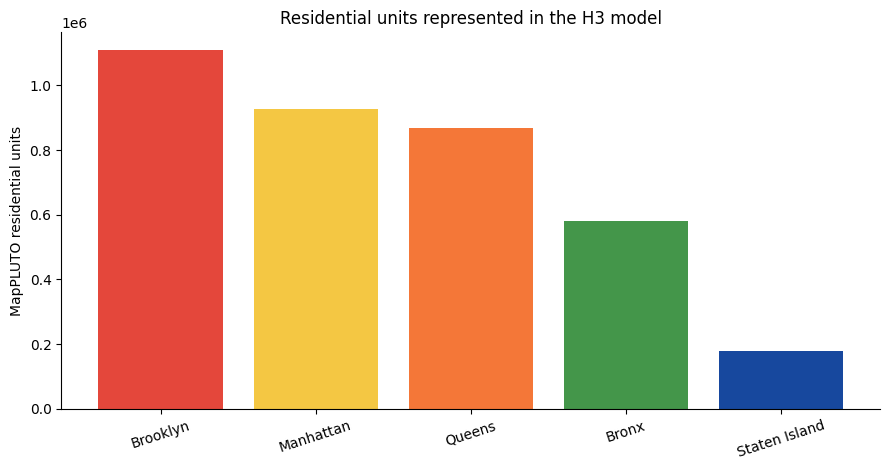

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(
    borough_summary["borough"],
    borough_summary["residential_units"],
    color=["#e4473b", "#f4c743", "#f47738", "#44964a", "#17489e"],
)
ax.set_title("Residential units represented in the H3 model")
ax.set_ylabel("MapPLUTO residential units")
ax.tick_params(axis="x", rotation=18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5. Measure first/last-mile station access coverage

In [7]:
candidate_count = access["candidate_count"]
entry = np.asarray(access["entry_stations"]).reshape(-1, candidate_count)
exit_ = np.asarray(access["exit_stations"]).reshape(-1, candidate_count)
access_coverage = pd.DataFrame({
    "candidate_count": range(candidate_count + 1),
    "entry_cells": [(entry >= 0).sum(axis=1).tolist().count(i) for i in range(candidate_count + 1)],
    "exit_cells": [(exit_ >= 0).sum(axis=1).tolist().count(i) for i in range(candidate_count + 1)],
})
access_coverage

,candidate_count,entry_cells,exit_cells
0,0,2470,2465
1,1,521,524
2,2,563,561
3,3,410,408
4,4,2202,2208


### 6. Audit scheduled transit matrices

In [8]:
matrix_rows = []
matrices = {}
for scenario in ["weekday-am", "weekday-midday", "weekend"]:
    matrix = np.fromfile(
        data_root / f"subway-{scenario}.bin", dtype="<u2"
    ).reshape(manifest["station_count"], manifest["station_count"])
    matrices[scenario] = matrix
    graph = json.loads(
        (data_root / f"subway-graph-{scenario}.json").read_text()
    )
    finite = matrix[matrix != manifest["unreachable_value"]] * manifest["matrix_unit_minutes"]
    matrix_rows.append({
        "scenario": scenario,
        "matrix_shape": str(matrix.shape),
        "unreachable_pairs": int((matrix == manifest["unreachable_value"]).sum()),
        "median_reachable_minutes": round(float(np.median(finite)), 1),
        "p90_reachable_minutes": round(float(np.percentile(finite, 90)), 1),
        "zero_diagonal": bool(np.all(np.diag(matrix) == 0)),
        "explicit_gtfs_transfer_edges": sum(
            bool(edge.get("explicit_gtfs")) for edge in graph["edges"]
        ),
    })
matrix_audit = pd.DataFrame(matrix_rows)
si_indices = stations.loc[stations["routes"].str.contains("SI"), "station_index"].to_numpy()
main_indices = stations.loc[~stations["routes"].str.contains("SI"), "station_index"].to_numpy()
weekend_matrix = matrices["weekend"]
staten_island_railway_disconnected = bool(
    np.all(weekend_matrix[np.ix_(si_indices, main_indices)] == manifest["unreachable_value"])
    and np.all(weekend_matrix[np.ix_(main_indices, si_indices)] == manifest["unreachable_value"])
)
assert staten_island_railway_disconnected
matrix_audit

,scenario,matrix_shape,unreachable_pairs,median_reachable_minutes,p90_reachable_minutes,zero_diagonal,explicit_gtfs_transfer_edges
0,weekday-am,"(496, 496)",19950,44.5,72.2,True,8210
1,weekday-midday,"(496, 496)",19950,46.0,74.5,True,6712
2,weekend,"(496, 496)",19950,47.8,75.8,True,4380


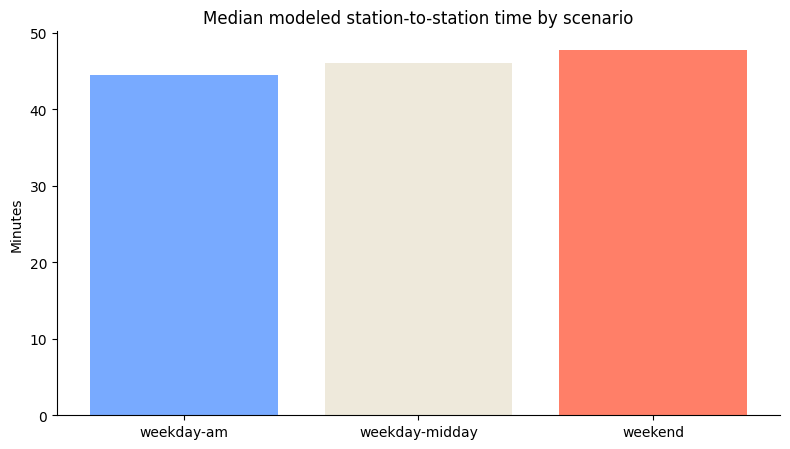

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.bar(
    matrix_audit["scenario"],
    matrix_audit["median_reachable_minutes"],
    color=["#78aaff", "#eee9db", "#ff7f68"],
)
ax.set_title("Median modeled station-to-station time by scenario")
ax.set_ylabel("Minutes")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 7. Inspect representative station pairs

In [10]:
def find_station(text):
    match = stations[stations["name"].str.contains(text, case=False, regex=False)]
    if match.empty:
        raise KeyError(text)
    return int(match.iloc[0]["station_index"]), match.iloc[0]["name"]

pairs = [
    ("116 St-Columbia University", "Grand Central-42 St"),
    ("Grand Central-42 St", "Atlantic Av-Barclays Ctr"),
    ("Flushing-Main St", "Times Sq-42 St"),
]
pair_rows = []
for origin_text, destination_text in pairs:
    origin, origin_name = find_station(origin_text)
    destination, destination_name = find_station(destination_text)
    row = {"origin": origin_name, "destination": destination_name}
    for scenario, matrix in matrices.items():
        value = int(matrix[origin, destination])
        row[scenario] = (
            None if value == manifest["unreachable_value"] else round(value * 0.1, 1)
        )
    pair_rows.append(row)
od_benchmarks = pd.DataFrame(pair_rows)
od_benchmarks

,origin,destination,weekday-am,weekday-midday,weekend
0,116 St-Columbia University,Grand Central-42 St,28.8,30.0,31.0
1,Grand Central-42 St,Atlantic Av-Barclays Ctr,25.2,26.0,25.0
2,Flushing-Main St,Times Sq-42 St,39.8,43.0,42.5


## Results

- Geometry, identifiers, residential assignment, station indexes, and matrix
  dimensions pass the notebook checks. The repository validation script also
  checks graph-to-matrix reconstruction.
- The browser uses OSMnx pedestrian shortest paths; small disconnected OSM
  fragments are filtered before cell and entrance snapping.
- The driving map uses a directed OSMnx graph with free-flow travel-time
  weights. It does not represent traffic or parking.
- Every residential H3 cell receives a housing-unit-weighted allocation from
  official block-group values; missing observations fall back to the official
  tract, borough, then city value without neighboring-area interpolation.
- Explicit MTA GTFS transfer records are used where present. The weekend graph
  combines Saturday and Sunday service and excludes weekday-only route
  patterns.
- Residential weighting prevents parks, airports, cemeteries, and water-heavy
  areas from counting as equal housing opportunity.
- Remaining direct-walk graph components reflect real pedestrian separation,
  including water barriers; Staten Island Railway stays disconnected from the
  main subway because no ferry mode is modeled.

## Takeaways & reflection

The strongest use of NYC TIME FIELD is comparative: it reveals how subway,
walking, and driving topology reshape the same nominal time budget. Keeping
travel mode separate from bar height lets the ACS rent model add housing context without
changing the meaning of the travel-time colors.

The project also makes visible what the model cannot know. A scheduled trip may
feel very different because of crowding, reliability, stairs, disability,
weather, safety perception, traffic, parking, or the cost of a missed
connection. ACS gross rent is also a survey estimate rather than asking rent.
Future work should add accessibility-aware paths, observed reliability,
traffic, and licensed listing data without presenting the result as a live
navigation product.